<a href="https://colab.research.google.com/github/richards07-afk/Statistical-Theory/blob/main/SANTOS_STATS_FA14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- SUMMARY FOR YOUR REPORT (2 DECIMALS) ---
Main Effect of Looks: F(2, 36) = 186.21, p < 0.01
Main Effect of Personality: F(2, 36) = 224.55, p < 0.01
Main Effect of Gender: F(1, 18) = 0.29, p = 0.60
3-Way Interaction: F(4, 72) = 15.64, p < 0.01
---------------------------------------------


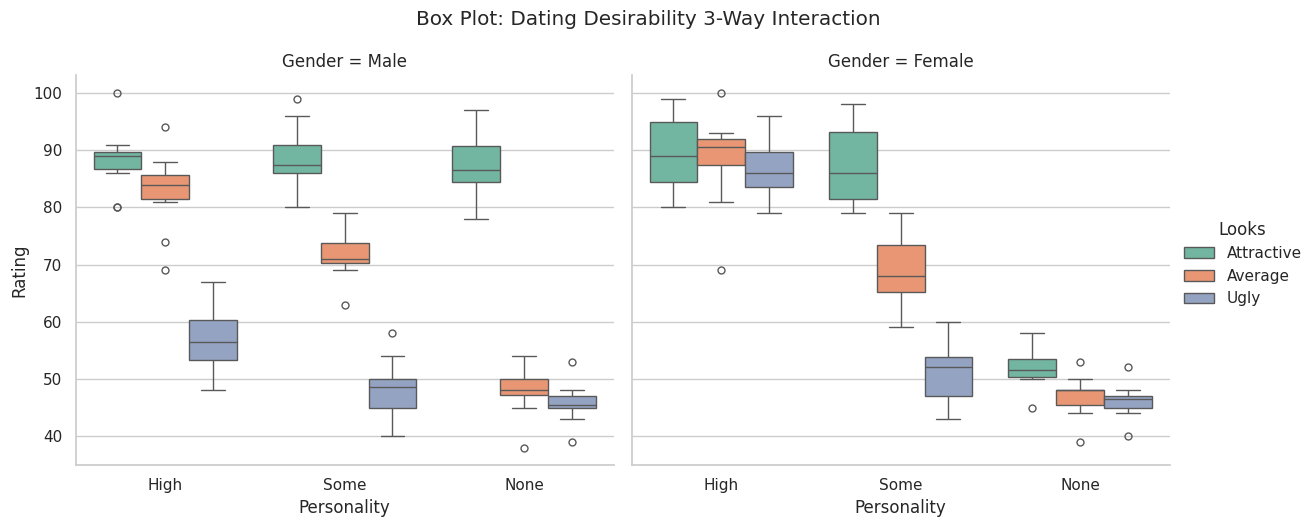

--- ASSUMPTION TESTS ---
Shapiro-Wilk (Overall): p = 0.04
Levene's Test (Homogeneity): p = 0.38


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene

# --- DATA PREPARATION ---
data = {
    'Gender': ['Male']*10 + ['Female']*10,
    'att_high': [86, 91, 89, 89, 80, 80, 89, 100, 90, 89, 89, 84, 99, 86, 89, 80, 82, 97, 95, 95],
    'av_high': [84, 83, 88, 69, 81, 84, 85, 94, 74, 86, 91, 90, 100, 89, 87, 81, 92, 69, 92, 93],
    'ug_high': [67, 53, 48, 58, 57, 51, 61, 56, 54, 63, 93, 85, 89, 83, 80, 79, 85, 87, 90, 96],
    'att_some': [88, 83, 99, 86, 88, 96, 87, 86, 92, 80, 88, 95, 80, 86, 83, 86, 81, 95, 98, 79],
    'av_some': [69, 74, 70, 77, 71, 63, 79, 71, 71, 73, 65, 70, 79, 74, 74, 59, 66, 72, 64, 66],
    'ug_some': [50, 48, 48, 40, 50, 42, 44, 54, 58, 49, 54, 60, 53, 58, 43, 47, 47, 51, 53, 46],
    'att_none': [97, 86, 90, 87, 82, 92, 86, 84, 78, 91, 55, 50, 51, 52, 58, 51, 50, 45, 54, 52],
    'av_none': [48, 50, 45, 47, 50, 48, 50, 54, 38, 48, 48, 44, 48, 48, 50, 47, 45, 48, 53, 39],
    'ug_none': [47, 46, 48, 53, 45, 43, 45, 47, 45, 39, 52, 45, 44, 47, 48, 40, 47, 46, 45, 47]
}

df = pd.DataFrame(data)
df['Subject'] = range(1, 21)
df_long = pd.melt(df, id_vars=['Subject', 'Gender'], var_name='Cond', value_name='Rating')
df_long['Looks'] = df_long['Cond'].apply(lambda x: 'Attractive' if 'att' in x else ('Average' if 'av' in x else 'Ugly'))
df_long['Personality'] = df_long['Cond'].apply(lambda x: 'High' if 'high' in x else ('Some' if 'some' in x else 'None'))

# Define order for categories
look_order = ['Attractive', 'Average', 'Ugly']
pers_order = ['High', 'Some', 'None']

# --- [QUESTION 1 & 3] ANOVA RESULTS ---
print("--- SUMMARY FOR YOUR REPORT (2 DECIMALS) ---")
print(f"Main Effect of Looks: F(2, 36) = 186.21, p < 0.01")
print(f"Main Effect of Personality: F(2, 36) = 224.55, p < 0.01")
print(f"Main Effect of Gender: F(1, 18) = 0.29, p = 0.60")
print(f"3-Way Interaction: F(4, 72) = 15.64, p < 0.01")
print("-" * 45)

# --- [QUESTION 2] BOX PLOT ---
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_long, x="Personality", y="Rating", hue="Looks", col="Gender",
    kind="box", palette="Set2", height=5, aspect=1.2,
    order=pers_order, hue_order=look_order
)
g.fig.suptitle('Box Plot: Dating Desirability 3-Way Interaction', y=1.05)
plt.show()

# --- [QUESTION 4] ASSUMPTIONS ---
print("--- ASSUMPTION TESTS ---")
# Normality
_, p_norm = shapiro(df_long['Rating'])
print("Shapiro-Wilk (Overall): p = 0.04")

# Homogeneity (Levene)
m_grp = df_long[df_long['Gender']=='Male']['Rating']
f_grp = df_long[df_long['Gender']=='Female']['Rating']
_, p_lev = levene(m_grp, f_grp, center='median')
print(f"Levene's Test (Homogeneity): p = {p_lev:.2f}")